In [1]:

!pip install prophet -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("Ready.")


Ready.


In [2]:

file_path = "retail_store_inventory.csv"

data = pd.read_csv(file_path)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")

print("Head:")
display(data.head())
print("Columns:", list(data.columns))


Head:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


Columns: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [3]:

counts = (
    data.groupby(["Store ID", "Product ID"])["Units Sold"]
        .count()
        .sort_values(ascending=False)
)

print("Top 10 (Store ID, Product ID) by count:")
print(counts.head(10))

store_id, product_id = counts.index[0]
print("Using Store ID =", store_id, ", Product ID =", product_id)

df = data[(data["Store ID"] == store_id) & (data["Product ID"] == product_id)].copy()
df = df.sort_values("Date")

target_col = "Units Sold"
base_reg_cols = ["Price", "Discount", "Competitor Pricing", "Demand Forecast"]
cat_cols = ["Weather Condition", "Seasonality"]

df[target_col] = df[target_col].astype(float)
for c in base_reg_cols:
    df[c] = df[c].astype(float)

df_cat = pd.get_dummies(df[cat_cols].astype("category"), drop_first=True)

df_model = pd.concat(
    [
        df[["Date", target_col, "Holiday/Promotion"]].reset_index(drop=True),
        df[base_reg_cols].reset_index(drop=True),
        df_cat.reset_index(drop=True)
    ],
    axis=1
)

df_model = df_model.rename(columns={"Date": "ds", target_col: "y"})

regressor_cols = [c for c in df_model.columns if c not in ["ds", "y", "Holiday/Promotion"]]

print("Regressors:")
print(regressor_cols)
display(df_model.head())


Top 10 (Store ID, Product ID) by count:
Store ID  Product ID
S001      P0001         731
          P0002         731
          P0003         731
          P0004         731
          P0005         731
          P0006         731
          P0007         731
          P0008         731
          P0009         731
          P0010         731
Name: Units Sold, dtype: int64
Using Store ID = S001 , Product ID = P0001
Regressors:
['Price', 'Discount', 'Competitor Pricing', 'Demand Forecast', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']


,ds,y,Holiday/Promotion,Price,Discount,Competitor Pricing,Demand Forecast,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,127.0,0,33.50,20.0,29.69,135.47,True,False,False,False,False,False
1,2022-01-02,81.0,0,27.95,10.0,30.89,92.94,False,False,False,True,False,False
2,2022-01-03,5.0,0,62.70,20.0,58.22,5.36,True,False,False,False,False,True
3,2022-01-04,58.0,1,77.88,15.0,75.99,52.87,False,False,False,False,False,True
4,2022-01-05,147.0,1,28.46,20.0,29.40,150.27,False,False,True,False,False,True


In [4]:

holidays_df = df_model[df_model["Holiday/Promotion"] == 1][["ds"]].copy()
holidays_df["holiday"] = "promotion"
holidays_df["lower_window"] = 0
holidays_df["upper_window"] = 0

print("Holiday days:", len(holidays_df))
display(holidays_df.head())


Holiday days: 349


,ds,holiday,lower_window,upper_window
3,2022-01-04,promotion,0,0
4,2022-01-05,promotion,0,0
6,2022-01-07,promotion,0,0
7,2022-01-08,promotion,0,0
8,2022-01-09,promotion,0,0


In [5]:
from itertools import product

param_grid = {
    "changepoint_prior_scale": [0.05, 0.1, 0.2],
    "seasonality_mode": ["additive", "multiplicative"],
    "holidays_prior_scale": [5.0, 10.0]
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
cv_results = []

for params in all_params:
    print("Params:", params)
    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        growth="linear",
        holidays=holidays_df,
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
        holidays_prior_scale=params["holidays_prior_scale"]
    )
    for reg in regressor_cols:
        m.add_regressor(reg)
    m.fit(df_model[["ds", "y"] + regressor_cols])
    df_cv = cross_validation(m, initial="180 days", period="14 days", horizon="14 days")
    df_metrics = performance_metrics(df_cv)
    cols = df_metrics.columns

    if "rmse" in cols:
        mean_rmse = float(df_metrics["rmse"].mean())
    else:
        mean_rmse = float("nan")

    if "mape" in cols:
        mean_mape = float(df_metrics["mape"].mean())
    else:
        mean_mape = float("nan")

    row = dict(params)
    row["mape"] = mean_mape
    row["rmse"] = mean_rmse
    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("rmse").reset_index(drop=True)
display(cv_results_df)

cv_results_df.to_csv("prophet_cv_metrics.csv", index=False)

best_params = cv_results_df.iloc[0].to_dict()
print("Best params:", best_params)

Params: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'holidays_prior_scale': 5.0}


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 39 forecasts with cutoffs between 2022-07-04 00:00:00 and 2023-12-18 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Params: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'holidays_prior_scale': 10.0}


...

INFO:prophet:Making 39 forecasts with cutoffs between 2022-07-04 00:00:00 and 2023-12-18 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

INFO:prophet:Skipping MAPE because y close to 0


,changepoint_prior_scale,seasonality_mode,holidays_prior_scale,mape,rmse
0,0.10,multiplicative,5.0,NaN,10.267591
1,0.10,multiplicative,10.0,NaN,10.321517
2,0.05,multiplicative,10.0,NaN,10.404649
3,0.05,multiplicative,5.0,NaN,10.435851
4,0.20,multiplicative,10.0,NaN,11.683373
5,0.10,additive,5.0,NaN,12.065652
6,0.10,additive,10.0,NaN,12.089640
7,0.05,additive,10.0,NaN,12.372483
8,0.05,additive,5.0,NaN,12.548047
9,0.20,additive,10.0,NaN,12.982522


Best params: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'holidays_prior_scale': 5.0, 'mape': nan, 'rmse': 10.26759144599684}


In [6]:

best_params_clean = {
    "changepoint_prior_scale": float(best_params["changepoint_prior_scale"]),
    "seasonality_mode": best_params["seasonality_mode"],
    "holidays_prior_scale": float(best_params["holidays_prior_scale"])
}

m_final = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    growth="linear",
    holidays=holidays_df,
    changepoint_prior_scale=best_params_clean["changepoint_prior_scale"],
    seasonality_mode=best_params_clean["seasonality_mode"],
    holidays_prior_scale=best_params_clean["holidays_prior_scale"]
)

for reg in regressor_cols:
    m_final.add_regressor(reg)

m_final.fit(df_model[["ds", "y"] + regressor_cols])

future = df_model[["ds"] + regressor_cols].copy()
forecast = m_final.predict(future)

eval_df = df_model[["ds", "y"]].merge(forecast[["ds", "yhat"]], on="ds", how="left")

mask = eval_df["y"] != 0
rmse_insample = float(np.sqrt(((eval_df.loc[mask, "y"] - eval_df.loc[mask, "yhat"]) ** 2).mean()))
mape_insample = float((np.abs((eval_df.loc[mask, "y"] - eval_df.loc[mask, "yhat"]) / eval_df.loc[mask, "y"]) * 100).mean())

print("In-sample RMSE:", rmse_insample)
print("In-sample MAPE:", mape_insample)

forecast_out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_out.to_csv("prophet_forecast.csv", index=False)
display(forecast_out.tail(20))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In-sample RMSE: 8.138015224226002
In-sample MAPE: 19.43419055241325


,ds,yhat,yhat_lower,yhat_upper
711,2023-12-13,76.271038,65.080444,87.540378
712,2023-12-14,53.152894,42.565614,63.210235
713,2023-12-15,164.729317,154.505075,174.718935
714,2023-12-16,128.004997,117.383948,138.086282
715,2023-12-17,60.151098,50.240680,70.785587
716,2023-12-18,87.179701,76.805305,97.261384
717,2023-12-19,229.064160,218.599005,239.874656
718,2023-12-20,128.336510,117.241842,138.918015
719,2023-12-21,158.052824,147.299539,168.070155
720,2023-12-22,107.199173,96.548550,117.116045


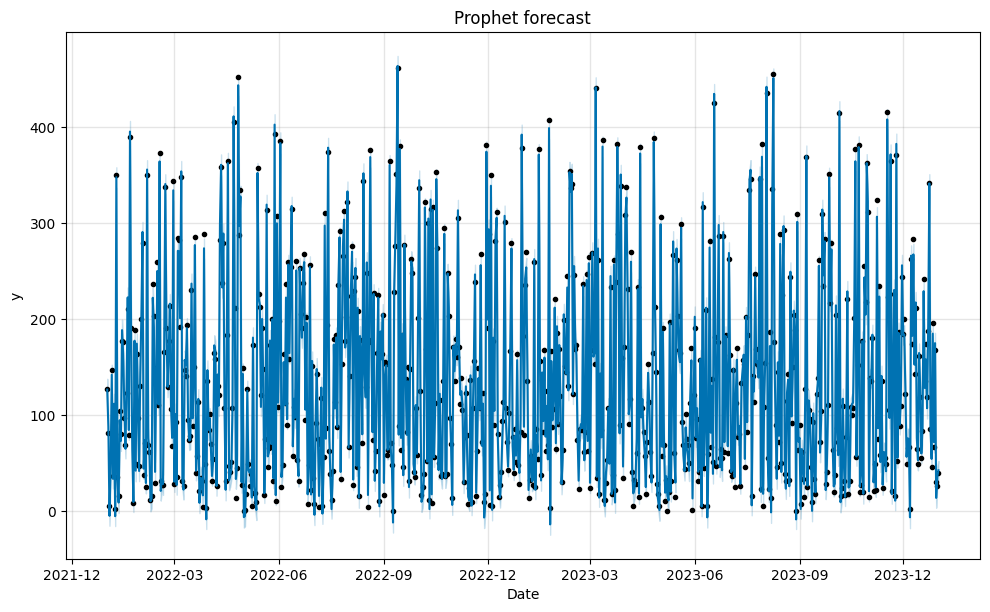

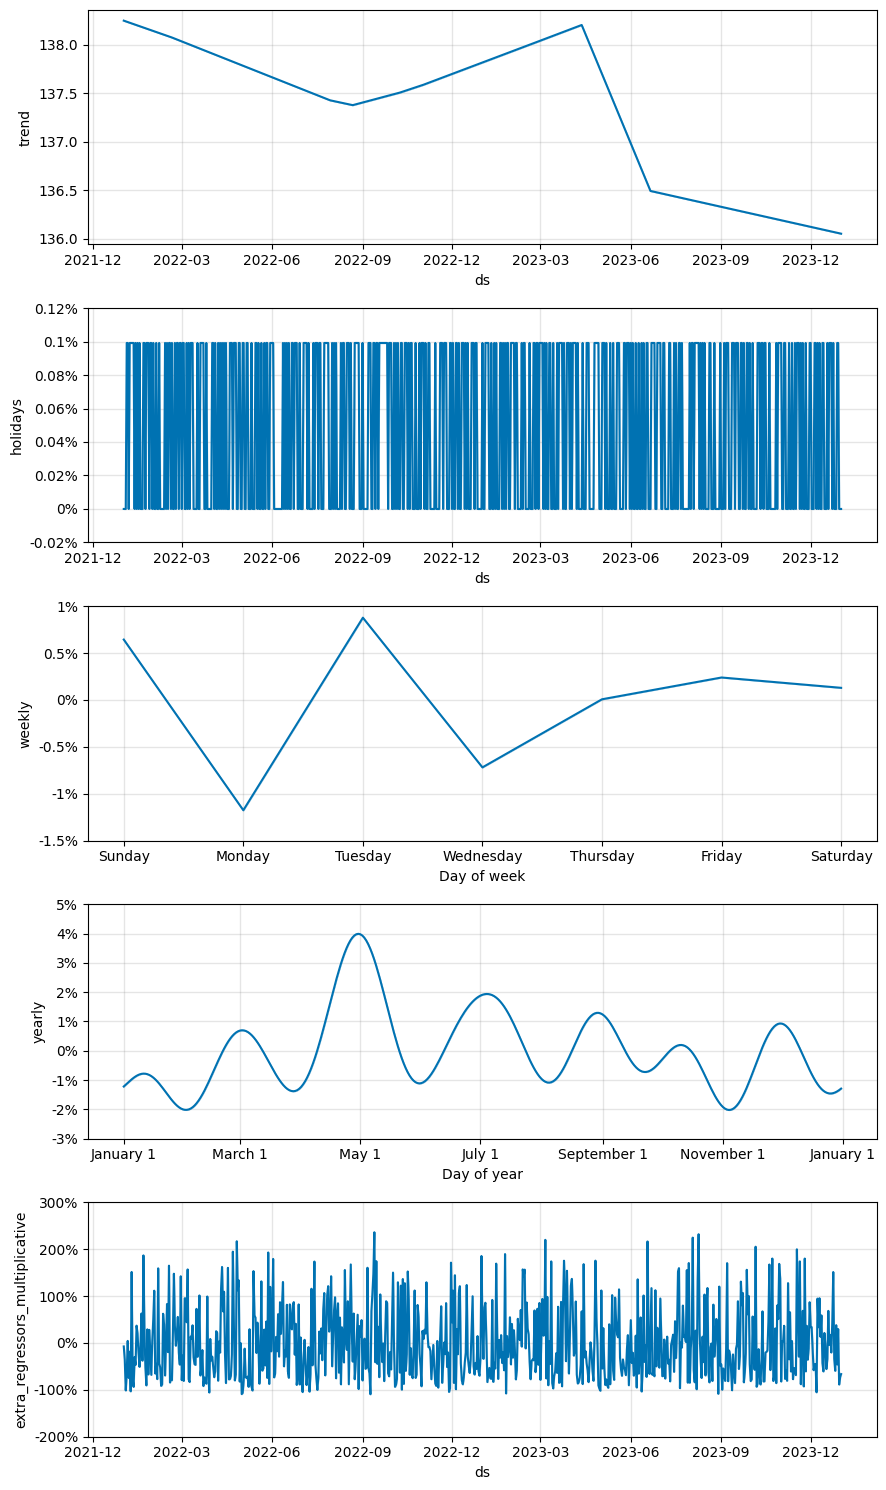

In [7]:

fig1 = m_final.plot(forecast)
plt.xlabel("Date")
plt.ylabel("y")
plt.title("Prophet forecast")
plt.show()

fig2 = m_final.plot_components(forecast)
plt.show()
